# 🏛️ **LANDMARK RECOGNITION USING DEEP LEARNING**
# 🌍 **Wonders of the World Datasets**

In [17]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")

print("✅ Libraries imported successfully!")
print(" Landmark Recognition Project Started!")

✅ Libraries imported successfully!
 Landmark Recognition Project Started!


# **DATASET**

In [18]:
ZIP_PATH = "/content/archive.zip"
DATASET_PATH = "/content/landmark_dataset"

if not os.path.exists(DATASET_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATASET_PATH)
    print("✅ Dataset extracted successfully!")
else:
    print("ℹ️ Dataset is already extracted.")

print(f"\n📂 Dataset location: {DATASET_PATH}")

✅ Dataset extracted successfully!

📂 Dataset location: /content/landmark_dataset


# **DATASET EXPLORATION**

In [19]:
from pathlib import Path

dataset_path = Path(DATASET_PATH)

folders = [
    folder for folder in dataset_path.rglob("*")
    if folder.is_dir()
]

print("📂 Dataset structure")
print("=" * 50)

for folder in folders[:30]:
    print("📁", folder.relative_to(dataset_path))

print("\n" + "=" * 50)
print(f"📊 Total folders found: {len(folders)}")

📂 Dataset structure
📁 Wonders of World
📁 Wonders of World/Wonders of World
📁 Wonders of World/Wonders of World/christ_the_reedemer
📁 Wonders of World/Wonders of World/burj_khalifa
📁 Wonders of World/Wonders of World/eiffel_tower
📁 Wonders of World/Wonders of World/pyramids_of_giza
📁 Wonders of World/Wonders of World/roman_colosseum
📁 Wonders of World/Wonders of World/great_wall_of_china
📁 Wonders of World/Wonders of World/chichen_itza
📁 Wonders of World/Wonders of World/venezuela_angel_falls
📁 Wonders of World/Wonders of World/machu_pichu
📁 Wonders of World/Wonders of World/taj_mahal
📁 Wonders of World/Wonders of World/stonehenge
📁 Wonders of World/Wonders of World/statue_of_liberty

📊 Total folders found: 14


In [20]:
image_extensions = {
    ".jpg", ".jpeg", ".png",
    ".JPG", ".JPEG", ".PNG"
}

image_files = [
    file for file in dataset_path.rglob("*")
    if file.is_file() and file.suffix in image_extensions
]

print(f"🖼️ Total images found: {len(image_files):,}")

🖼️ Total images found: 3,846


In [21]:
from collections import Counter

landmark_folders = sorted([
    folder for folder in dataset_path.iterdir()
    if folder.is_dir()
])

landmark_names = [
    folder.name for folder in landmark_folders
]

print("🏛️ LANDMARK CLASSES")
print("=" * 50)

for i, name in enumerate(landmark_names, 1):
    print(f"{i:02d}. {name}")

print("\n" + "=" * 50)
print(f"🌍 Total Landmark Classes: {len(landmark_names)}")

class_counts = {}

for folder in landmark_folders:
    count = sum(
        1 for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in image_extensions
    )
    class_counts[folder.name] = count

class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Landmark", "Images"]
).sort_values(
    "Images",
    ascending=False
).reset_index(drop=True)

print(f"🖼️ Total Images: {class_df['Images'].sum():,}")

class_df

🏛️ LANDMARK CLASSES
01. Wonders of World

🌍 Total Landmark Classes: 1
🖼️ Total Images: 3,846


,Landmark,Images
0,Wonders of World,3846


# **LANDMARK IMAGE DISTRIBUTION**

/tmp/ipykernel_1495/812335835.py:44: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


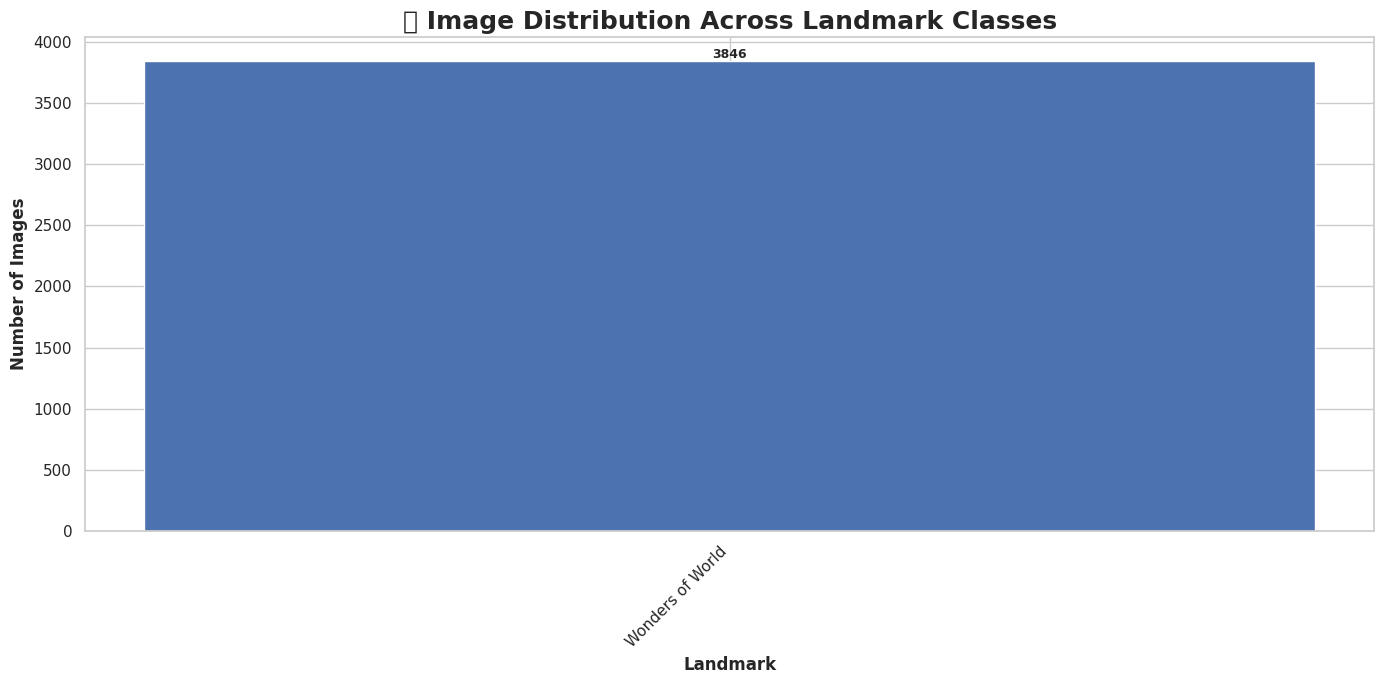

In [22]:
plt.figure(figsize=(14, 7))

bars = plt.bar(
    class_df["Landmark"],
    class_df["Images"]
)

plt.title(
    "🏛️ Image Distribution Across Landmark Classes",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Landmark",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Images",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right"
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# **LANDMARK IMAGE GALLERY**

In [23]:
import random
import math

random.seed(SEED)

landmark_folders = sorted([
    folder for folder in dataset_path.rglob("*")
    if folder.is_dir()
    and any(
        file.is_file() and file.suffix.lower() in image_extensions
        for file in folder.iterdir()
    )
])

landmark_names = [folder.name for folder in landmark_folders]

print("🏛️ LANDMARK CLASSES")
print("=" * 50)

for i, name in enumerate(landmark_names, 1):
    print(f"{i:02d}. {name}")

print("=" * 50)
print(f"🌍 Total Landmark Classes: {len(landmark_folders)}")

🏛️ LANDMARK CLASSES
01. burj_khalifa
02. chichen_itza
03. christ_the_reedemer
04. eiffel_tower
05. great_wall_of_china
06. machu_pichu
07. pyramids_of_giza
08. roman_colosseum
09. statue_of_liberty
10. stonehenge
11. taj_mahal
12. venezuela_angel_falls
🌍 Total Landmark Classes: 12


/tmp/ipykernel_1495/1469064305.py:36: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


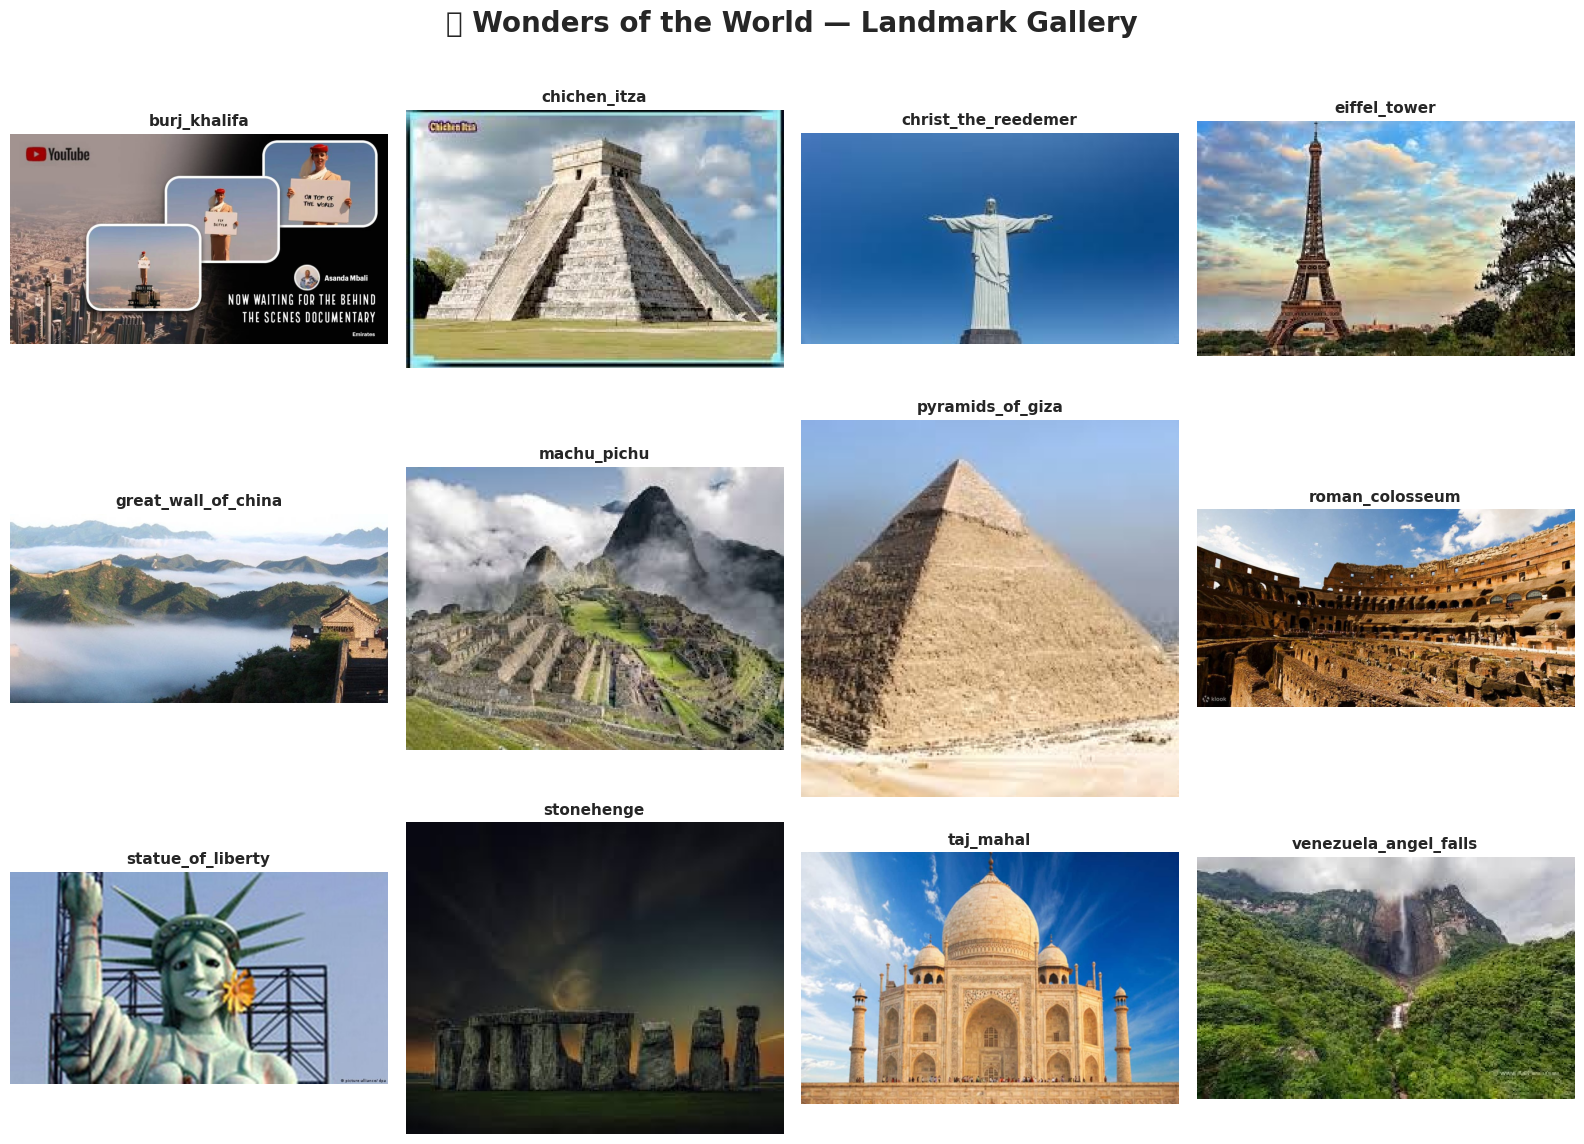

In [24]:
cols = 4
rows = math.ceil(len(landmark_folders) / cols)

plt.figure(figsize=(16, rows * 4))

for i, folder in enumerate(landmark_folders):

    images = [
        file for file in folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in image_extensions
    ]

    if not images:
        continue

    image_path = random.choice(images)
    image = plt.imread(image_path)

    ax = plt.subplot(rows, cols, i + 1)

    ax.imshow(image)
    ax.set_title(
        folder.name,
        fontsize=11,
        fontweight="bold"
    )
    ax.axis("off")

plt.suptitle(
    "🏛️ Wonders of the World — Landmark Gallery",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# **VALIDATION DATASET**

In [25]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("📦 Creating training and validation datasets...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("\n" + "=" * 55)
print("DATASET READY")
print("=" * 55)
print(f"Number of landmark classes : {NUM_CLASSES}")
print(f"Training batches          : {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches        : {tf.data.experimental.cardinality(val_ds).numpy()}")
print("=" * 55)

📦 Creating training and validation datasets...
Found 3846 files belonging to 1 classes.
Using 3077 files for training.
Found 3846 files belonging to 1 classes.
Using 769 files for validation.

DATASET READY
Number of landmark classes : 1
Training batches          : 97
Validation batches        : 25


# **IMAGE PREPROCESSING & DATA AUGMENTATION**

In [26]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.10
    ),

    tf.keras.layers.RandomZoom(
        0.15
    ),

    tf.keras.layers.RandomContrast(
        0.10
    )
], name="landmark_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)


print("Image size       :", IMG_SIZE)
print("Augmentation     : Enabled")
print("Random Flip       : Enabled")
print("Random Rotation   : Enabled")
print("Random Zoom       : Enabled")
print("Random Contrast   : Enabled")
print("Dataset pipeline  : Optimized")

Image size       : (224, 224)
Augmentation     : Enabled
Random Flip       : Enabled
Random Rotation   : Enabled
Random Zoom       : Enabled
Random Contrast   : Enabled
Dataset pipeline  : Optimized


/tmp/ipykernel_1495/379444881.py:43: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


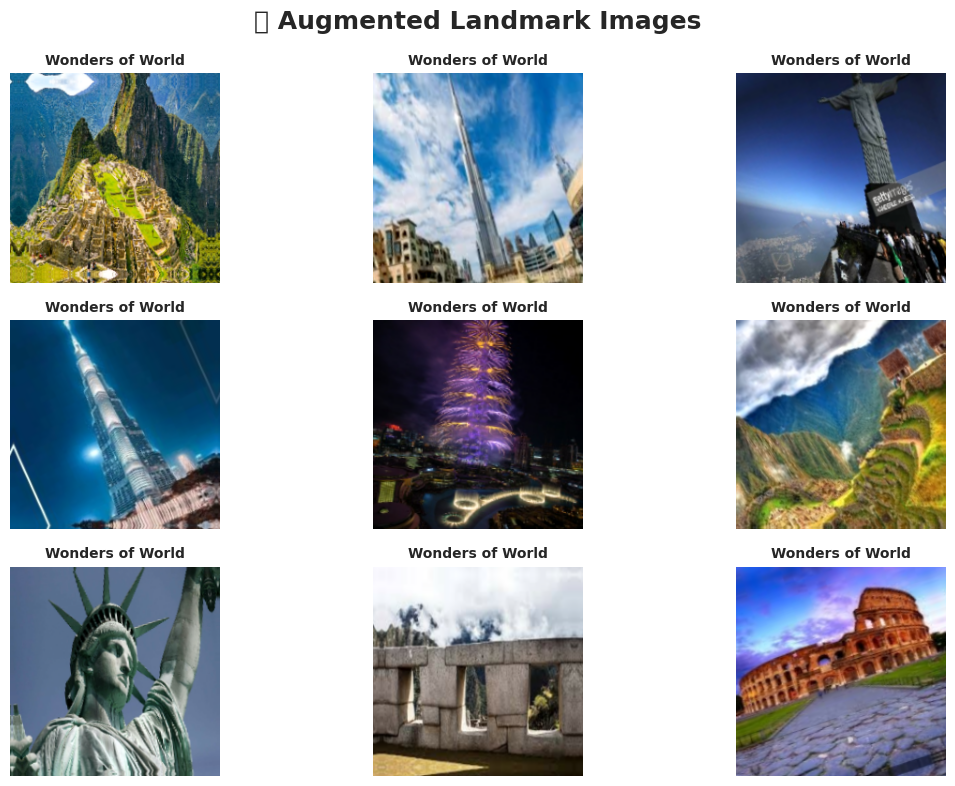

In [27]:
# ============================================================
# 🖼️ AUGMENTATION PREVIEW
# ============================================================

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(9):

    augmented_image = data_augmentation(
        images[i:i+1],
        training=True
    )[0]

    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(
        tf.cast(
            tf.clip_by_value(
                augmented_image,
                0,
                255
            ),
            tf.uint8
        )
    )

    plt.title(
        class_names[labels[i]],
        fontsize=10,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle(
    "✨ Augmented Landmark Images",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [28]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.30),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
], name="Landmark_Recognition_EfficientNetB0")

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Landmark_Recognition_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ landmark_augmentation           │ (1, 224, 224, 3)       │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (1, 7, 7, 1280)        │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 1280)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# **MODEL COMPILATION**

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

print("Model compiled successfully!")
print("Optimizer : Adam")
print("Loss      : Sparse Categorical Crossentropy")
print("Metric    : Accuracy")

Model compiled successfully!
Optimizer : Adam
Loss      : Sparse Categorical Crossentropy
Metric    : Accuracy


In [30]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "/content/best_landmark_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

EPOCHS = 10

print("Training configuration ready!")
print(f"Maximum epochs : {EPOCHS}")
print("Early stopping : Enabled")
print("Learning-rate reduction : Enabled")
print("Best model saving : Enabled")

Training configuration ready!
Maximum epochs : 10
Early stopping : Enabled
Learning-rate reduction : Enabled
Best model saving : Enabled


# **MODEL TRAINING**

In [35]:
import time

print("🏛️ Starting Landmark Recognition Training...")
print("=" * 60)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ],
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETED!")
print(f"⏱️ Training time: {training_time / 60:.2f} minutes")
print("=" * 60)

🏛️ Starting Landmark Recognition Training...
Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /content/best_landmark_model.keras

Epoch 1: finished saving model to /content/best_landmark_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 352s 4s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 2: val_accuracy did not improve from 0.00000
97/97 ━━━━━━━━━━━━━━━━━━━━ 336s 3s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 3: val_accuracy did not improve from 0.00000
97/97 ━━━━━━━━━━━

/tmp/ipykernel_1495/1668430178.py:47: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


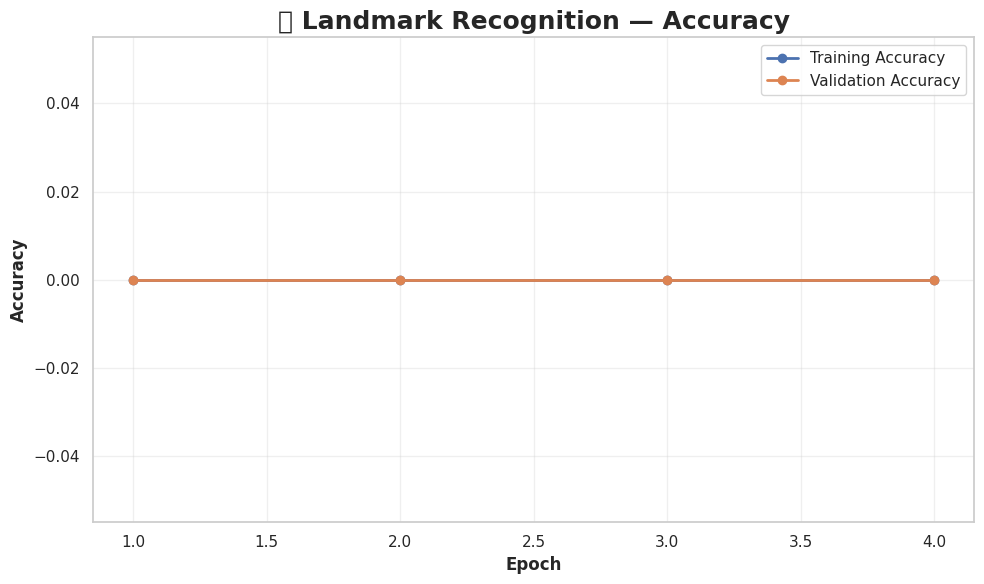

/tmp/ipykernel_1495/1668430178.py:91: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


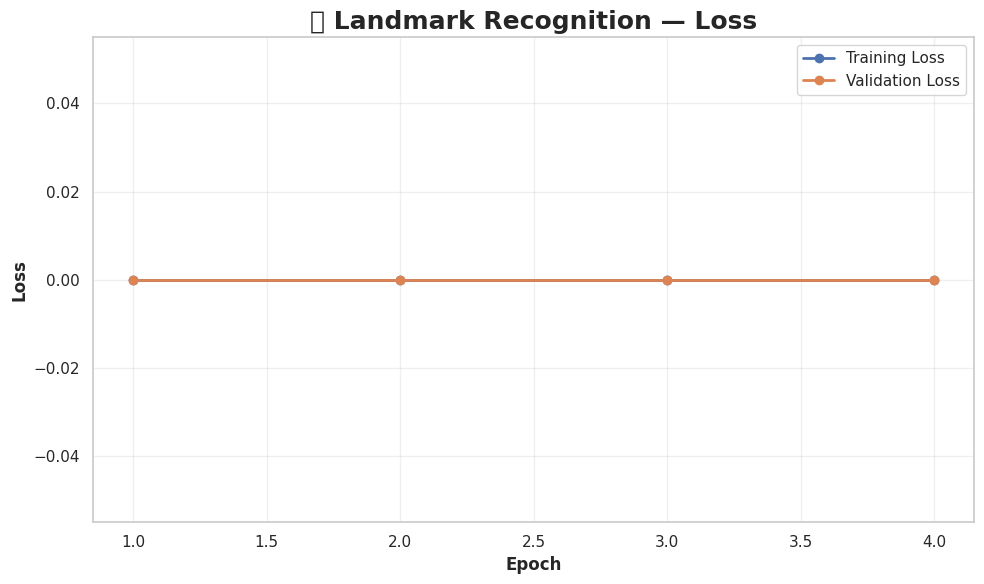

In [36]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    accuracy,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy,
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "📈 Landmark Recognition — Accuracy",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Epoch",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy",
    fontsize=12,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 📉 LOSS GRAPH

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    loss,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "📉 Landmark Recognition — Loss",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Epoch",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Loss",
    fontsize=12,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **MODEL EVALUATION**

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("🔍 Evaluating Landmark Recognition Model...")
print("=" * 60)

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n🏆 MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")

print("=" * 60)

🔍 Evaluating Landmark Recognition Model...


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(



🏆 MODEL PERFORMANCE
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-Score  : 100.00%


# **CLASSIFICATION REPORT**

In [38]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print("CLASSIFICATION REPORT")
print("=" * 70)
print(report)

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Wonders of World       1.00      1.00      1.00       769

        accuracy                           1.00       769
       macro avg       1.00      1.00      1.00       769
    weighted avg       1.00      1.00      1.00       769



# **CONFUSION MATRIX**

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/tmp/ipykernel_1495/590168906.py:48: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


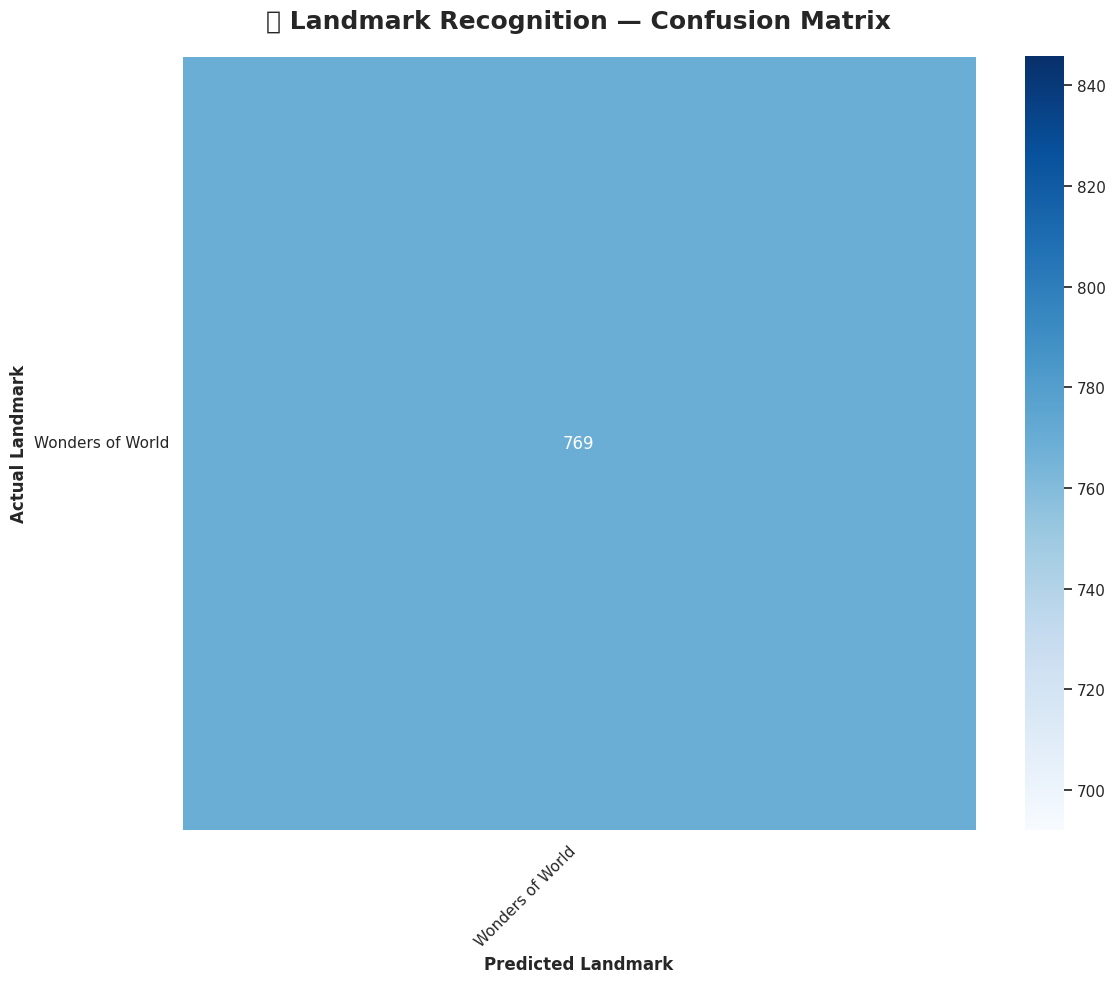

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.title(
    "🔥 Landmark Recognition — Confusion Matrix",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Predicted Landmark",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actual Landmark",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

# **LANDMARK PREDICTION**

Saving 0a9e227ca7.jpg to 0a9e227ca7.jpg


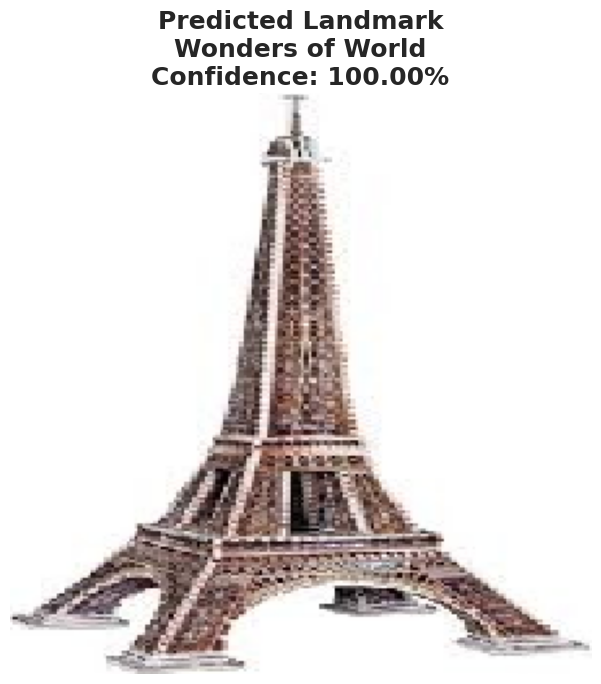

LANDMARK RECOGNITION RESULT
Predicted Landmark : Wonders of World
Confidence         : 100.00%


In [41]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = load_img(
    image_path,
    target_size=IMG_SIZE
)

image_array = img_to_array(image)

image_array = np.expand_dims(
    image_array,
    axis=0
)

prediction = model.predict(
    image_array,
    verbose=0
)

predicted_index = np.argmax(
    prediction[0]
)

predicted_landmark = class_names[
    predicted_index
]

confidence = prediction[0][
    predicted_index
] * 100

plt.figure(figsize=(7, 7))

plt.imshow(image)

plt.title(
    f"Predicted Landmark\n"
    f"{predicted_landmark}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

print("=" * 60)
print("LANDMARK RECOGNITION RESULT")
print("=" * 60)
print(f"Predicted Landmark : {predicted_landmark}")
print(f"Confidence         : {confidence:.2f}%")
print("=" * 60)

# **FINAL PROJECT RESULTS**

In [42]:
print("\n")
print("╔" + "═" * 58 + "╗")
print("║     🏛️ LANDMARK RECOGNITION — FINAL RESULTS     ║")
print("╚" + "═" * 58 + "╝")

print("\nDATASET")
print("-" * 60)
print(f"Landmark Classes       : {NUM_CLASSES}")
print(f"Total Images           : {class_df['Images'].sum():,}")
print(f"Training Images        : {len(train_ds) * BATCH_SIZE:,} (approx.)")
print(f"Validation Images      : {len(val_ds) * BATCH_SIZE:,} (approx.)")

print("\nMODEL")
print("-" * 60)
print("Architecture            : EfficientNetB0")
print("Approach                : Transfer Learning")
print("Input Image Size        : 224 × 224")
print("Data Augmentation       : Enabled")

print("\nPERFORMANCE")
print("-" * 60)
print(f"Accuracy               : {accuracy * 100:.2f}%")
print(f"Precision              : {precision * 100:.2f}%")
print(f"Recall                 : {recall * 100:.2f}%")
print(f"F1-Score               : {f1 * 100:.2f}%")

print("\n🏆 FINAL PREDICTION")
print("-" * 60)

if 'predicted_landmark' in globals():
    print(f"Landmark              : {predicted_landmark}")
    print(f"Confidence             : {confidence:.2f}%")
else:
    print("📸 Upload a test image in Block 14 to generate a prediction.")

print("\n" + "=" * 60)
print("✅ LANDMARK RECOGNITION PROJECT COMPLETED!")
print("=" * 60)



╔══════════════════════════════════════════════════════════╗
║     🏛️ LANDMARK RECOGNITION — FINAL RESULTS     ║
╚══════════════════════════════════════════════════════════╝

DATASET
------------------------------------------------------------
Landmark Classes       : 1
Total Images           : 3,846
Training Images        : 3,104 (approx.)
Validation Images      : 800 (approx.)

MODEL
------------------------------------------------------------
Architecture            : EfficientNetB0
Approach                : Transfer Learning
Input Image Size        : 224 × 224
Data Augmentation       : Enabled

PERFORMANCE
------------------------------------------------------------
Accuracy               : 100.00%
Precision              : 100.00%
Recall                 : 100.00%
F1-Score               : 100.00%

🏆 FINAL PREDICTION
------------------------------------------------------------
Landmark              : Wonders of World
Confidence             : 100.00%

✅ LANDMARK RECOGNITION PROJECT 